# Getting started with scEcho
This notebook walks through a complete scEcho analysis on a real dataset: day-59
human fetal retina, profiled with paired single-cell RNA and ATAC. It is meant
as a starting point — follow it top to bottom once to see how the pieces fit
together, then adapt the steps to your own data.
What scEcho does. During differentiation, gene expression and chromatin
accessibility do not change in lockstep — one can lead or lag the other. scEcho
identifies cell states where the two modalities are desynchronized, and the
genes and regulatory elements that drive that desynchronization. The analysis
has two stages:

* Echo States — finds cell states that are better resolved in one modality
than the other.
* Echo Features — finds the genes (or regulatory features) underlying those
desynchronized states.

What you need before starting. scEcho works from an AnnData object that
already contains, for the same cells, a separate low-dimensional
representation for each modality (here, diffusion-map eigenvectors for RNA and
ATAC stored in .obsm) and at least one feature layer to analyze. Building
those representations is upstream of scEcho and not covered here.

## Imports

In [1]:
import warnings
# Silence two noisy informational warnings from transitive dependencies:
#   * jaxopt (Mellon transitive dep, in maintenance mode)
#   * joblib/loky CPU-count probe (one-shot UserWarning on first parallel call)
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jaxopt")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import anndata

import kompot
import scEcho

In [2]:
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = [8, 8]
matplotlib.rcParams["figure.dpi"] = 125
matplotlib.rcParams["image.cmap"] = "Spectral_r"

# no bounding boxes or axis:
matplotlib.rcParams["axes.spines.bottom"] = "on"
matplotlib.rcParams["axes.spines.top"] = "off"
matplotlib.rcParams["axes.spines.left"] = "on"
matplotlib.rcParams["axes.spines.right"] = "off"

## Data

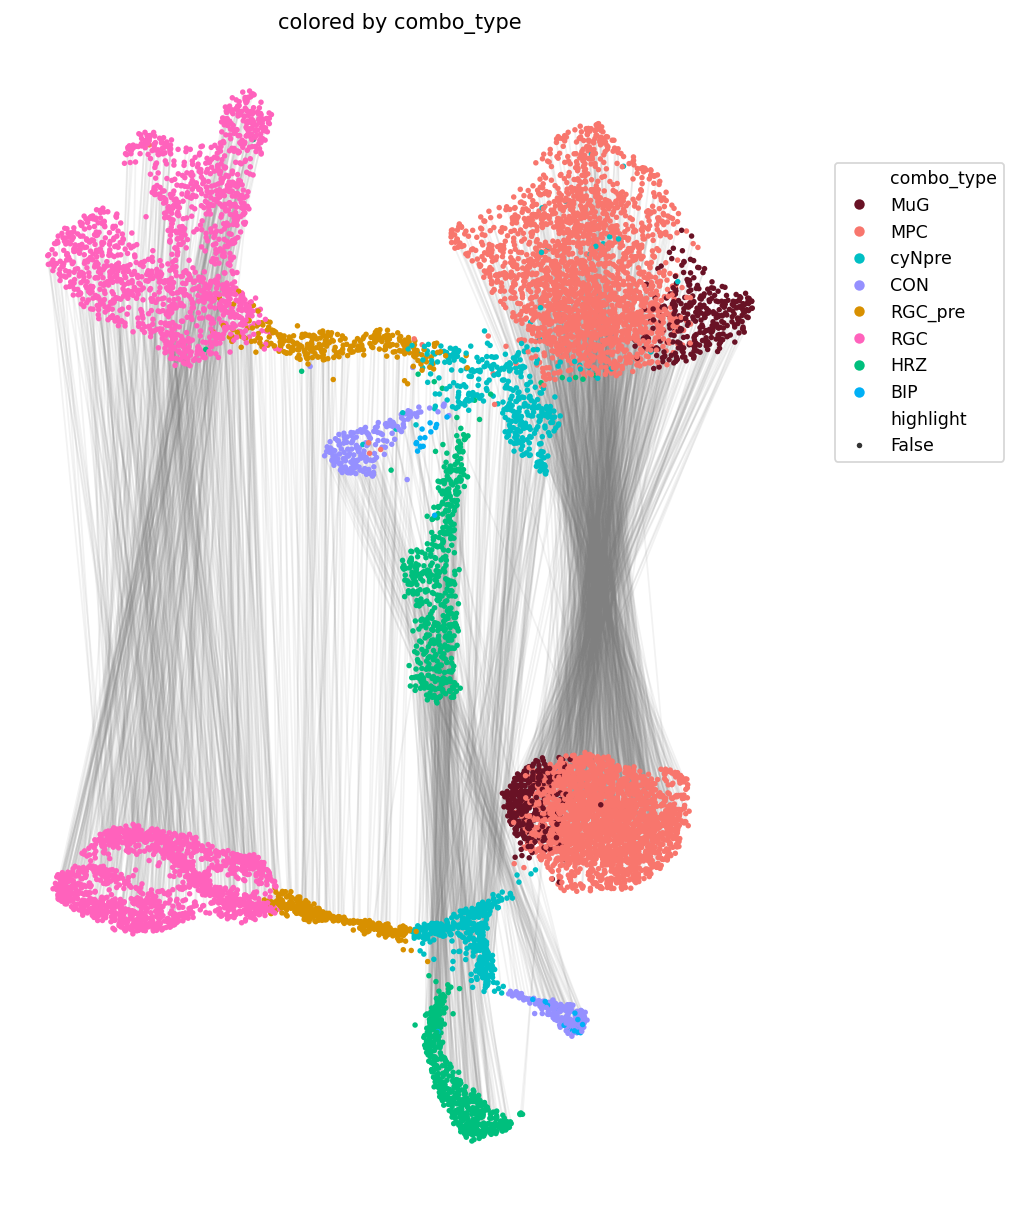

In [3]:
retina_ad = anndata.read_h5ad("D59_retina.h5ad")


l_plot = scEcho.plotting.linked_plot(retina_ad,
                                  embedding1 = "RNA_UMAP_2d",
                                  embedding2 = "ATAC_umap_rotated", 
                                  downsample_lines_frac=.3, 
                                  line_alpha=.1, 
                                  color_by="combo_type")

# Echo states

**Echo States** identifies cell states that are better resolved in one modality than the other.

Key arguments:

- `obsm_key1`, `obsm_key2` — the two `.obsm` representations to compare, these should point to the diffusion map representations for each modality.
- `pval_threshold` — significance cutoff for calling a state desynchronized.
- `log_fold_change_threshold` — minimum density log-fold-change for a state to count as desynchronized. Raising it makes the call more conservative.
- `ls_factor` — length-scale factor for the density estimator.

The function modifies `retina_ad` in place, writing per-cell density results and a `direction_RNA_v_ATAC` label into `.obs`.

  0%|          | 0/2 [00:00<?, ?it/s]

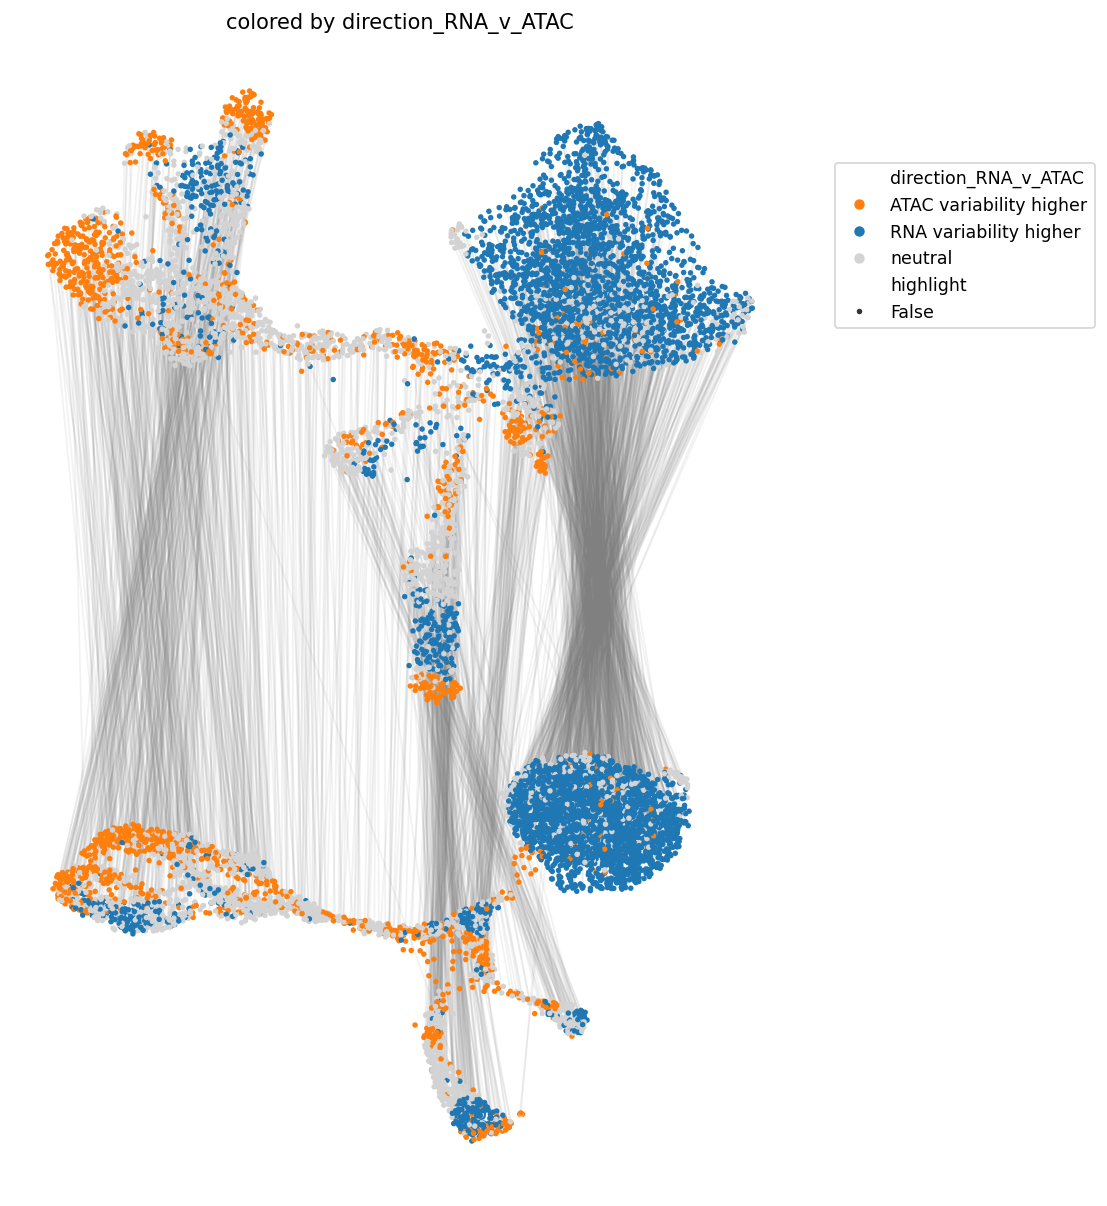

In [4]:
scEcho.Echo_states.dn_comp_obsm(retina_ad,
    obsm_key1='DM_EigenVectors_RNA',
    obsm_key2='DM_EigenVectors_ATAC',                     
    pval_threshold=0.05,
    log_fold_change_threshold=.7, 
                ls_factor = 2
)

l_plot = scEcho.plotting.linked_plot(retina_ad,
                                  embedding1 = "RNA_UMAP_2d",
                                  embedding2 = "ATAC_umap_rotated", 
                                  downsample_lines_frac=.3, 
                                  line_alpha=.1, 
                                  color_by="direction_RNA_v_ATAC")

## Volcano plot of desynchronized states

`plot_desynchronized_state_volcano` shows the Echo States results as a volcano plot: density log-fold change between the two modalities on the x-axis, significance on the y-axis. Cells that did not pass the significance and fold-change thresholds (`direction == "neutral"`) are drawn in grey in the background; significant cells are drawn on top, colored by `hue_col`. Dashed lines mark the log-fold-change and p-value cutoffs.

- `hue_col` — column in `.obs` used to color the significant cells (here, cell type).
- `lfc_threshold`, `pval_threshold` — where the guide lines are drawn; set these to match the thresholds you used in `dn_comp_obsm`.

This plot must be run after Echo States — it reads the density-comparison columns that `dn_comp_obsm` writes into `.obs`.

/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/plotting.py:948: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


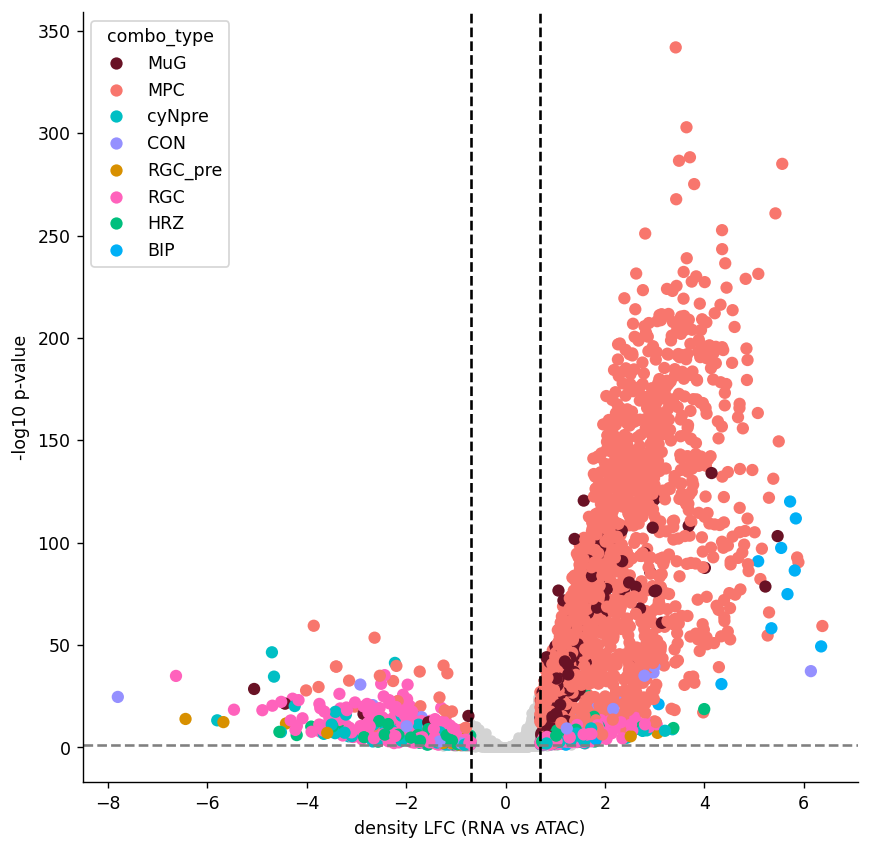

In [5]:
vl = scEcho.plotting.plot_desynchronized_state_volcano(retina_ad, 
                                                       hue_col = "combo_type", 
                                                       figsize=(8, 8))

## Summarize by cell type

`plot_direction_fractions` breaks down, for each group in `obs_col`, the fraction of cells that are RNA-resolved, ATAC-resolved, or neutral. This is the quickest way to see which populations carry the most desynchronization.

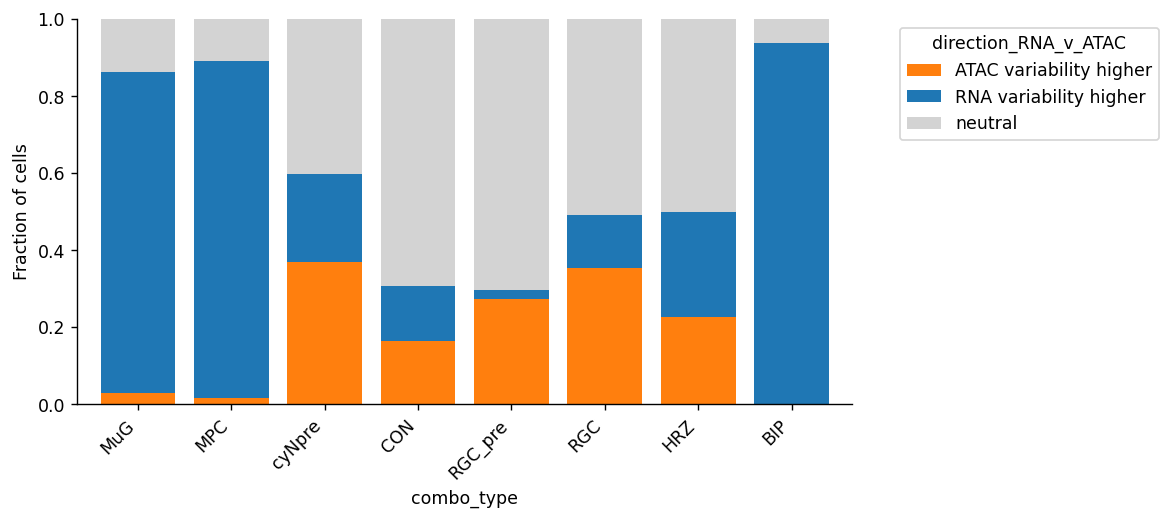

In [6]:
pbar = scEcho.plotting.plot_direction_fractions(retina_ad, obs_col = "combo_type", figsize=(8, 4))

# Echo Features

Echo Features identifies the features that are driving change in one modality and not the other. This is done by running `run_echo_features`, which for each layer predicts every feature from both modality representations, compares how well each representation explains it, and tests significance against a null model. Results are written into `retina_ad.varm`.

Key arguments:

- `obs_col` — the cell grouping to compute statistics within.
- `layers` — list of `.layers` keys to analyze.
- `sigma`, `ls` — Gaussian-process hyperparameters, used throughout the pipeline.

In [7]:
scEcho.Echo_features.run_echo_features(
    retina_ad,
    obs_col="combo_type",
    layers=["RNA_lognorm_counts"],
    sigma=0.1,
    ls=10 ** (-0.5),
)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Computing weighted Mahalanobis distances:   0%|          | 0/48 [00:00<?, ?it/s]

Computing weighted Mahalanobis distances:   0%|          | 0/48 [00:00<?, ?it/s]

Computing weighted Mahalanobis distances:   0%|          | 0/48 [00:00<?, ?it/s]

...

/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:600: RuntimeWarning: divide by zero encountered in divide
  res[null_col] = mse_null_diff / null_var
/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:600: RuntimeWarning: invalid value encountered in divide
  res[null_col] = mse_null_diff / null_var
/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:607: UserWarning: 3553 features have zero variance in group 'HRZ' of layer 'RNA_lognorm_counts_null' and will be excluded from null mean/SD calculation.
  warnings.warn(


Computing weighted Mahalanobis distances:   0%|          | 0/48 [00:00<?, ?it/s]

/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:600: RuntimeWarning: divide by zero encountered in divide
  res[null_col] = mse_null_diff / null_var
/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:600: RuntimeWarning: invalid value encountered in divide
  res[null_col] = mse_null_diff / null_var
/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:607: UserWarning: 5330 features have zero variance in group 'RGC_pre' of layer 'RNA_lognorm_counts_null' and will be excluded from null mean/SD calculation.
  warnings.warn(


Computing weighted Mahalanobis distances:   0%|          | 0/48 [00:00<?, ?it/s]

/fh/fast/setty_m/user/dotto/nexus/work/echo-polish/scEcho/src/scEcho/Echo_features.py:580: UserWarning: Group 'BIP' has 16 cells which is below min_cells=50 — skipping.
  warnings.warn(


## Volcano plot of feature results

`plot_scores` shows the per-feature results for one group (`c`). The x-axis is the difference in variance explained between modalities; the y-axis is the Mahalanobis distance, a measure of how strongly a feature is desynchronized.

- `c` — which group from `obs_col` to plot.
- `n_features_label` — how many top features to label.
- `ncells_cutoff` — drop features supported by too few cells in this group.
- `interactive` — `False` for a static matplotlib plot, `True` for a plotly plot with hover labels.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


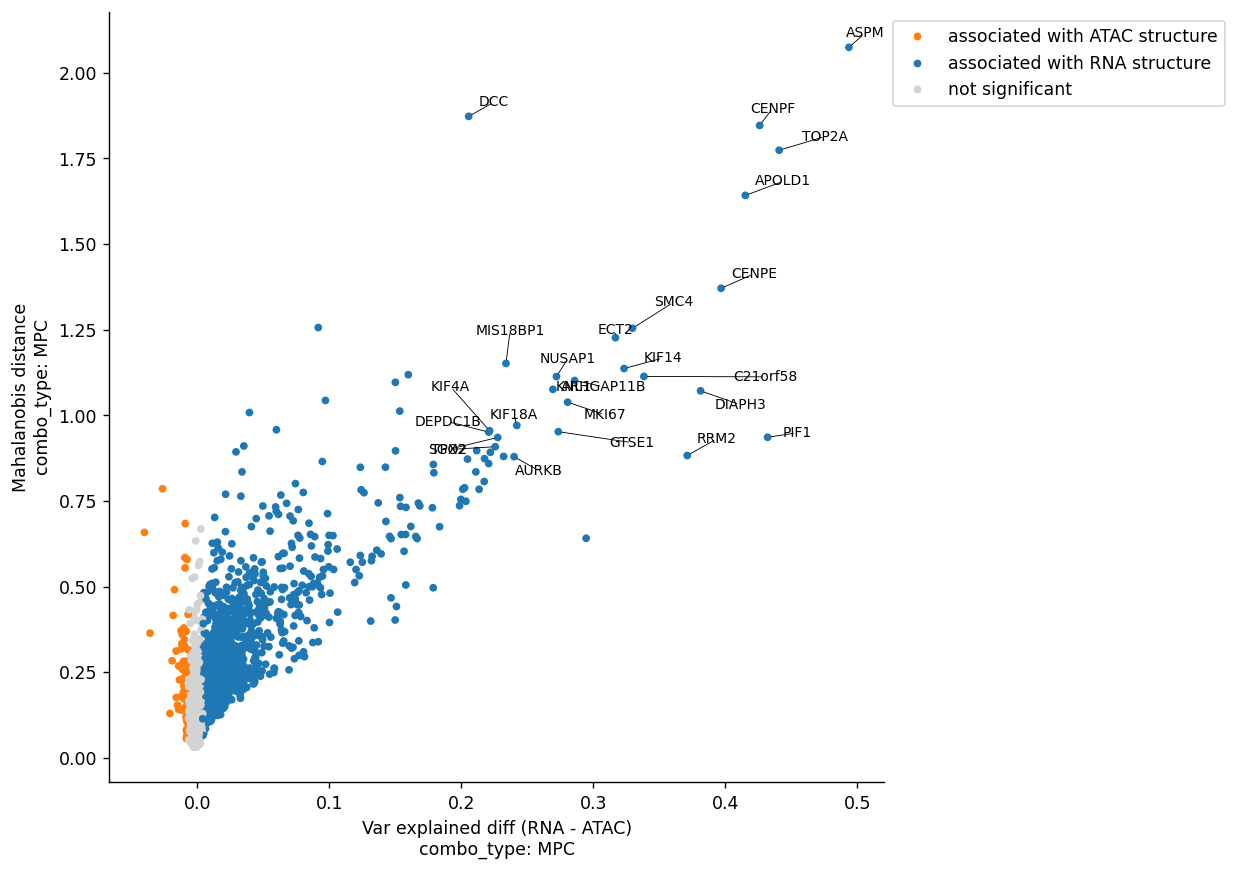

In [8]:
p = scEcho.plotting.plot_scores(retina_ad,
                                obs_col = "combo_type",
                                c = "MPC", 
                                n_features_label=25, 
                                ncells_cutoff=30,
                                layer = "RNA_lognorm_counts",
                                interactive=False, s=20)

## Extract the desynchronized gene list

`get_reconstruction_results` pulls the per-feature result table for one group out of `.varm` as a tidy DataFrame. Here we request the `MPC` (multipotent progenitor) group and filter it to genes that are significantly associated with RNA structure.

In [9]:
MPC_res = scEcho.Echo_features.get_reconstruction_results(retina_ad,
                                         "RNA_lognorm_counts",
                                         grouping = "combo_type",
                                         group = "MPC",
                                         min_cells=30)


MPC_gns = MPC_res.loc[(MPC_res["var_explained_diff_RNA_lognorm_counts_combo_type_MPC_direction"] == 'associated with RNA structure') & 
    (MPC_res["ncells_RNA_lognorm_counts_combo_type_MPC"] > 30)]
MPC_gns

,MSE_combo_type_MPC_RNA,MSE_combo_type_MPC_ATAC,MSE_combo_type_MPC_diff,mean_LFC_combo_type_MPC,MHD_combo_type_MPC_RNA_vs_ATAC,ncells_RNA_lognorm_counts_combo_type_MPC,mean_val_combo_type_MPC,RNA_lognorm_counts_var_combo_type_MPC,RNA_lognorm_counts_var_explained_RNA_combo_type_MPC,RNA_lognorm_counts_var_explained_ATAC_combo_type_MPC,var_explained_diff_RNA_lognorm_counts_combo_type_MPC,MSE_null_diff_combo_type_MPC,var_explained_diff_RNA_lognorm_counts_null_combo_type_MPC,var_explained_diff_RNA_lognorm_counts_null_combo_type_MPC_combo_type_MPC_mean,var_explained_diff_RNA_lognorm_counts_null_combo_type_MPC_combo_type_MPC_sd,var_explained_diff_RNA_lognorm_counts_combo_type_MPC_pval,var_explained_diff_RNA_lognorm_counts_combo_type_MPC_fdr,var_explained_diff_RNA_lognorm_counts_combo_type_MPC_sig,var_explained_diff_RNA_lognorm_counts_combo_type_MPC_direction,MHD_null_combo_type_MPC_RNA_vs_ATAC
HES4,2.082351,2.104775,0.022424,-0.006956,0.207440,426,0.705464,2.104825,0.989322,0.999976,0.010654,-0.001850,-0.001221,-0.001304,0.002099,1.229269e-08,1.135951e-07,True,associated with RNA structure,0.246634
CCNL2,1.656354,1.663651,0.007297,-0.006418,0.130466,335,0.543185,1.657123,0.999536,1.003939,0.004403,-0.002229,-0.001374,-0.001304,0.002099,6.558548e-03,3.623301e-02,True,associated with RNA structure,0.133740
GNB1,2.814160,2.847863,0.033703,0.003271,0.256332,603,1.028217,2.848294,0.988016,0.999849,0.011833,0.002624,0.000846,-0.001304,0.002099,3.916731e-10,3.851692e-09,True,associated with RNA structure,0.253238
AL139246.5,0.241592,0.242734,0.001142,0.002549,0.165516,38,0.064951,0.242787,0.995074,0.999780,0.004705,-0.000606,-0.002719,-0.001304,0.002099,4.205166e-03,2.400997e-02,True,associated with RNA structure,0.180355
NPHP4,1.482165,1.501159,0.018994,0.003893,0.189872,290,0.474600,1.502123,0.986714,0.999358,0.012645,0.001400,0.001180,-0.001304,0.002099,3.052386e-11,3.098231e-10,True,associated with RNA structure,0.219347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFF2,2.172843,2.185948,0.013105,0.002535,0.193419,427,0.717517,2.181715,0.995933,1.001940,0.006007,0.001882,0.001005,-0.001304,0.002099,4.974020e-04,3.276723e-03,True,associated with RNA structure,0.215544
HMGB3,0.432765,0.442423,0.009657,0.001789,0.284277,85,0.132615,0.441540,0.980128,1.002000,0.021872,-0.000025,-0.000054,-0.001304,0.002099,2.472503e-28,3.250326e-27,True,associated with RNA structure,0.376802
GABRA3,0.510796,0.515405,0.004609,0.002823,0.166049,95,0.152015,0.515428,0.991013,0.999956,0.008943,-0.000594,-0.000879,-0.001304,0.002099,1.056868e-06,8.829639e-06,True,associated with RNA structure,0.126865
PLXNA3,0.233335,0.234870,0.001535,-0.002905,0.180202,42,0.067414,0.234330,0.995756,1.002305,0.006549,0.000051,0.000100,-0.001304,0.002099,1.836942e-04,1.275877e-03,True,associated with RNA structure,0.114479


## Functional enrichment of the gene list

The desynchronized gene list can be used for further study. For example, here we hand it to kompot's StringDB report to ask what biological processes are enriched.

<Axes: xlabel='mlog10(fdr)', ylabel='description'>

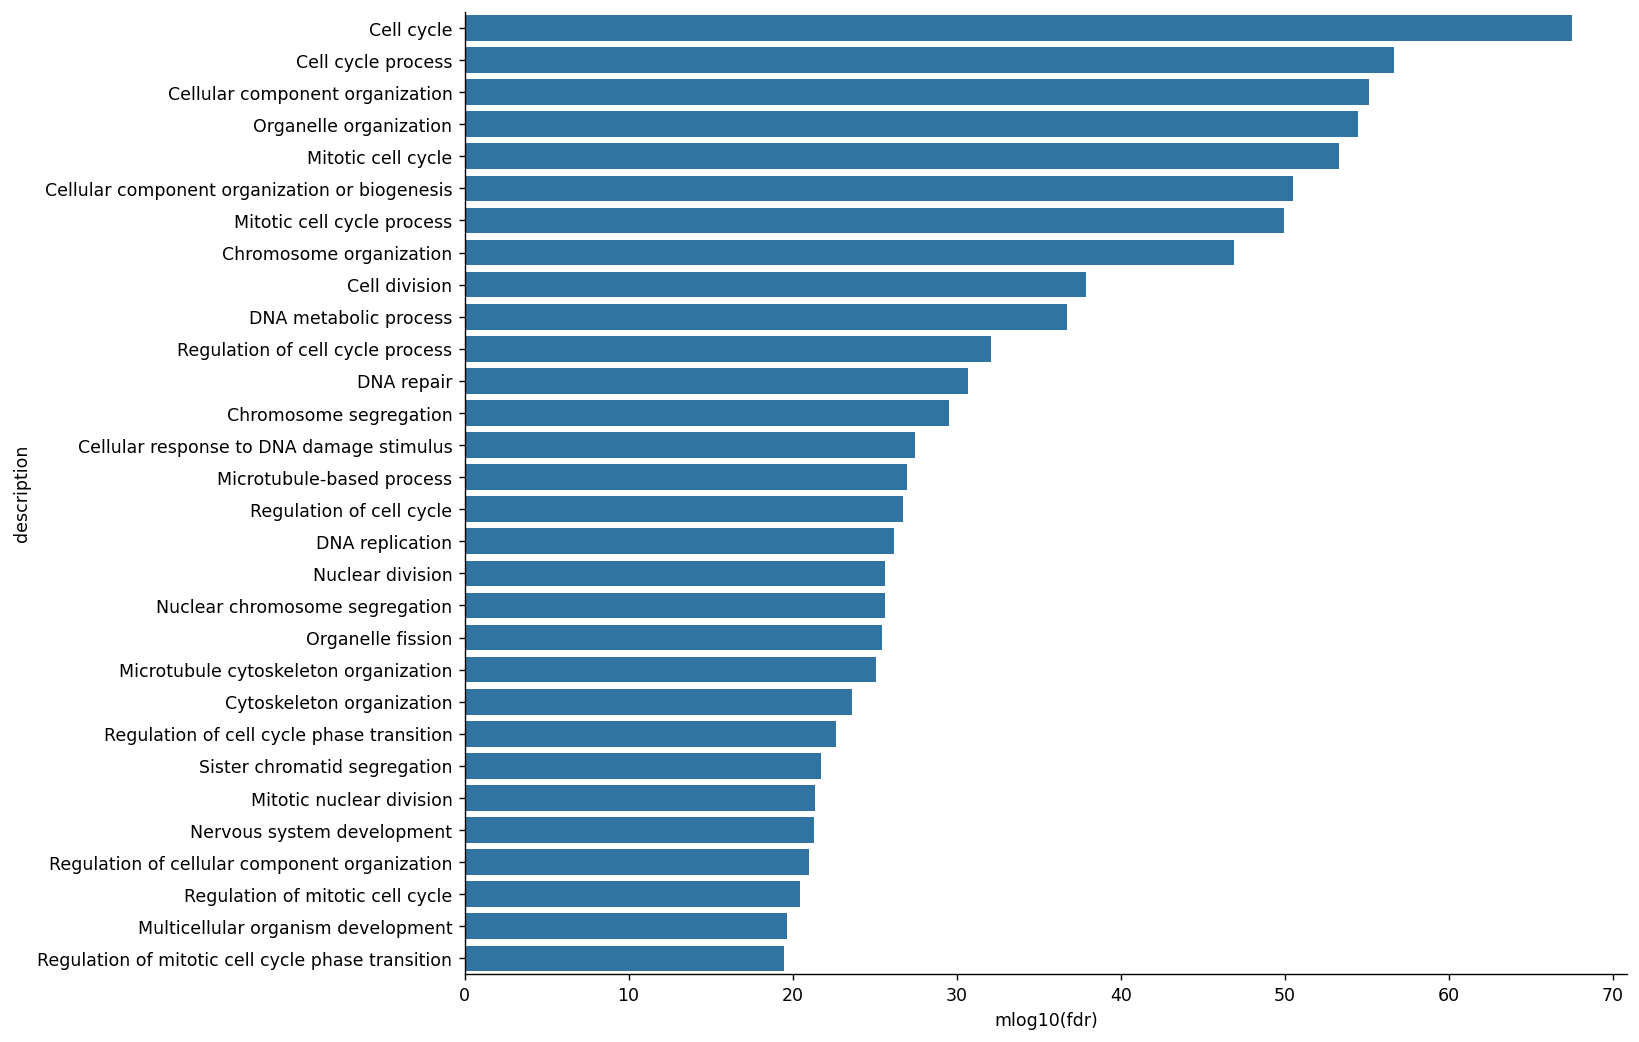

In [10]:
MPC_report = kompot.plot.StringDBReport(
    MPC_gns.index,
    species_id=9606,
    include_enrichment=True
)

mpc_terms = MPC_report.get_functional_enrichment()
mpc_terms["mlog10(fdr)"] = -np.log10(mpc_terms["fdr"])


mpc_terms = mpc_terms.sort_values("mlog10(fdr)", ascending=False)
fig, ax = plt.subplots(1,1, figsize = (12, 10))
sns.barplot(mpc_terms.head(30), y="description", x="mlog10(fdr)", ax = ax)